<a href="https://colab.research.google.com/github/Niloverz/FinalProject-DS/blob/main/FinalProject_MuhammadRyanAfandi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup dan Import Library

In [ ]:
# 1. Library untuk manipulasi data
import pandas as pd
import numpy as np

# 2. Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Library untuk preprocessing dan modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 4. Library untuk model machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# 5. Library untuk evaluasi model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 6. Import sklearn untuk cek versi (PERBAIKAN)
import sklearn

# 7. Setting tampilan (opsional, biar rapi)
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("Semua library berhasil diimport")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

Semua library berhasil diimport
Pandas version: 2.2.2
NumPy version: 2.0.2
Scikit-learn version: 1.6.1


Load Library dan Data

In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Shape dataset: {df.shape}")
print(f"Total data points: {df.shape[0] * df.shape[1]:,}")
print("\n5 baris pertama:")

df.info()

Shape dataset: (891, 12)
Total data points: 10,692

5 baris pertama:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


EDA (Exploratory Data Analysis)

Cek Kualitas Data

In [ ]:
# Cek Missing Values
print("="*40)
print("CEK MISSING VALUES")
print("="*40)
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Cek Data Duplikat
print("\n" + "="*40)
print("CEK DATA DUPLIKAT")
print("="*40)
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

CEK MISSING VALUES
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Total missing values: 866

CEK DATA DUPLIKAT
Jumlah baris duplikat: 0


Statistik Deskriptif Fitur Numerik

In [ ]:
# Statistik deskriptif untuk fitur numerik
print("="*50)
print("STATISTIK DESKRIPTIF FITUR NUMERIK")
print("="*50)

# Pilih kolom numerik saja
kolom_numerik = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']

# Tampilkan statistik deskriptif
print(df[kolom_numerik].describe())

STATISTIK DESKRIPTIF FITUR NUMERIK
              Age        Fare       SibSp       Parch      Pclass
count  714.000000  891.000000  891.000000  891.000000  891.000000
mean    29.699118   32.204208    0.523008    0.381594    2.308642
std     14.526497   49.693429    1.102743    0.806057    0.836071
min      0.420000    0.000000    0.000000    0.000000    1.000000
25%     20.125000    7.910400    0.000000    0.000000    2.000000
50%     28.000000   14.454200    0.000000    0.000000    3.000000
75%     38.000000   31.000000    1.000000    0.000000    3.000000
max     80.000000  512.329200    8.000000    6.000000    3.000000


Distribusi Usia

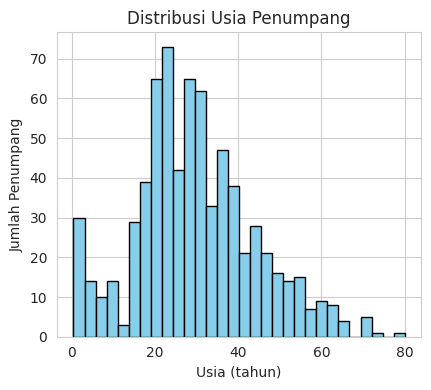

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(df['Age'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Distribusi Usia Penumpang')
plt.xlabel('Usia (tahun)')
plt.ylabel('Jumlah Penumpang')

plt.tight_layout()
plt.show()

Distribusi Harga Tiket

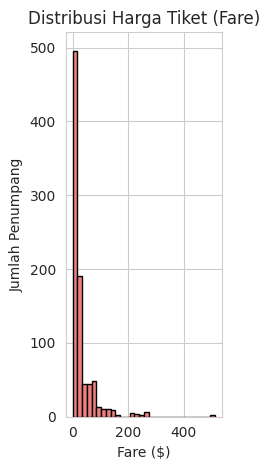

In [ ]:
plt.subplot(1, 3, 2)
plt.hist(df['Fare'], bins=30, color='lightcoral', edgecolor='black')
plt.title('Distribusi Harga Tiket (Fare)')
plt.xlabel('Fare ($)')
plt.ylabel('Jumlah Penumpang')

plt.tight_layout()
plt.show()

Distribusi Kelas

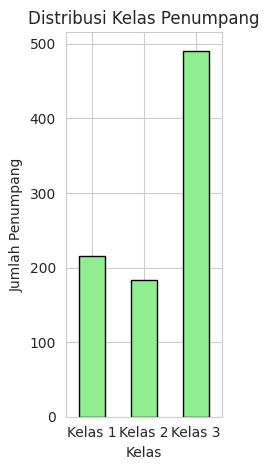

In [ ]:
plt.subplot(1, 3, 3)
df['Pclass'].value_counts().sort_index().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Distribusi Kelas Penumpang')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Penumpang')
plt.xticks([0,1,2], ['Kelas 1', 'Kelas 2', 'Kelas 3'], rotation=0)

plt.tight_layout()
plt.show()

Boxplot

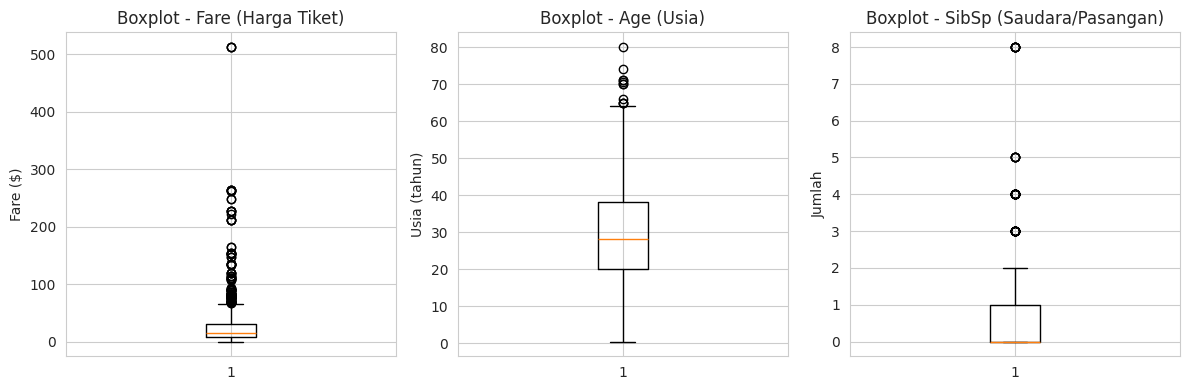

In [ ]:
plt.figure(figsize=(12, 4))

# Boxplot 1: Fare (harga tiket)
plt.subplot(1, 3, 1)
plt.boxplot(df['Fare'].dropna())
plt.title('Boxplot - Fare (Harga Tiket)')
plt.ylabel('Fare ($)')

# Boxplot 2: Age (usia)
plt.subplot(1, 3, 2)
plt.boxplot(df['Age'].dropna())
plt.title('Boxplot - Age (Usia)')
plt.ylabel('Usia (tahun)')

# Boxplot 3: SibSp (saudara/pasangan)
plt.subplot(1, 3, 3)
plt.boxplot(df['SibSp'].dropna())
plt.title('Boxplot - SibSp (Saudara/Pasangan)')
plt.ylabel('Jumlah')

plt.tight_layout()
plt.show()

Data Preprocessing

Justifiikasi : Missing Values & Duplikat

In [ ]:
# 1. CEK MISSING VALUES
print("\n1. CEK MISSING VALUES")
missing_count = df.isnull().sum()
missing_total = df.isnull().sum().sum()

print("Jumlah missing values per kolom:")
print(missing_count[missing_count > 0])  # Hanya tampilkan yang ada missing
print(f"\nTOTAL missing values: {missing_total}")

# 2. CEK DUPLIKAT
print("\n2. CEK DATA DUPLIKAT")
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicate_count}")

print("\n3. JUSTIFIKASI TINDAKAN:")
print("- Age (177 missing) → diisi MEDIAN (tahan outlier)")
print("- Cabin (687 missing) → DIHAPUS (>77% kosong)")
print("- Embarked (2 missing) → diisi MODUS (nilai terbanyak)")
print("- Duplikat (0) → TIDAK PERLU DIHAPUS")

print("\n")
print(f"Missing values : {'ADA' if missing_total > 0 else 'TIDAK ADA'} ({missing_total} total)")
print(f"Data duplikat  : {'ADA' if duplicate_count > 0 else 'TIDAK ADA'} ({duplicate_count} baris)")
print(f"Status         : {'PERLU PREPROCESSING' if missing_total > 0 else 'SIAP DIGUNAKAN'}")


1. CEK MISSING VALUES
Jumlah missing values per kolom:
Age         177
Cabin       687
Embarked      2
dtype: int64

TOTAL missing values: 866

2. CEK DATA DUPLIKAT
Jumlah baris duplikat: 0

3. JUSTIFIKASI TINDAKAN:
- Age (177 missing) → diisi MEDIAN (tahan outlier)
- Cabin (687 missing) → DIHAPUS (>77% kosong)
- Embarked (2 missing) → diisi MODUS (nilai terbanyak)
- Duplikat (0) → TIDAK PERLU DIHAPUS


Missing values : ADA (866 total)
Data duplikat  : TIDAK ADA (0 baris)
Status         : PERLU PREPROCESSING


Menangani Missing Values

In [ ]:
# 1. Isi missing values pada kolom Age dengan MEDIAN
df['Age'] = df['Age'].fillna(df['Age'].median())
print("\nKolom 'Age' telah diisi dengan MEDIAN")

# 2. Isi missing values pada kolom Embarked dengan MODUS
modus_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(modus_embarked)
print(f"Kolom 'Embarked' telah diisi dengan MODUS ('{modus_embarked}')")

# 3. Hapus kolom Cabin
if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)
    print("Kolom 'Cabin' telah dihapus (missing >77%)")
else:
    print("Kolom 'Cabin' sudah tidak ada")

# 4. Hapus kolom yang tidak diperlukan (jika masih ada)
for col in ['PassengerId', 'Name', 'Ticket']:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)
        print(f"✓ Kolom '{col}' telah dihapus")
    else:
        print(f"Kolom '{col}' sudah tidak ada")

# 5. Cek hasil akhir
print("\nSESUDAH PREPROCESSING")
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Jumlah kolom sesudah: {df.shape[1]}")
print(f"Kolom yang tersisa: {list(df.columns)}")
print("\nData sekarang BERSIH dan siap ke tahap Data Processing")


Kolom 'Age' telah diisi dengan MEDIAN
Kolom 'Embarked' telah diisi dengan MODUS ('S')
Kolom 'Cabin' telah dihapus (missing >77%)
✓ Kolom 'PassengerId' telah dihapus
✓ Kolom 'Name' telah dihapus
✓ Kolom 'Ticket' telah dihapus

SESUDAH PREPROCESSING
Total missing values: 0
Jumlah kolom sesudah: 8
Kolom yang tersisa: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Data sekarang BERSIH dan siap ke tahap Data Processing


Data Processing

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 1. ENCODING (Ubah teks ke angka)
print("\n1. PROSES ENCODING:")

# Encoding kolom Sex (male/female → 0/1)
le_sex = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'])
print("✓ Kolom 'Sex' telah di-encode (male=1, female=0)")

# Encoding kolom Embarked (S/C/Q → 0,1,2)
le_embarked = LabelEncoder()
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])
print("✓ Kolom 'Embarked' telah di-encode")

# 2. SCALING (Normalisasi fitur numerik)
print("\n2. PROSES SCALING:")

scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])
print("✓ Kolom 'Age' dan 'Fare' telah di-scale")

# 3. PISAHKAN FITUR (X) DAN TARGET (y)
print("\n3. PISAHKAN X DAN y:")

X = df.drop('Survived', axis=1)
y = df['Survived']

print(f"X (fitur) : {X.shape[0]} baris x {X.shape[1]} kolom")
print(f"y (target): {y.shape[0]} baris")

# 4. SPLIT DATA (Training 80%, Testing 20%)
print("\n4. SPLIT DATA TRAIN & TEST:")
print("-"*30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape[0]} baris")
print(f"X_test : {X_test.shape[0]} baris")

# 5. RINGKASAN
print(f"""
Encoding selesai   : Sex dan Embarked sekarang angka
Scaling selesai    : Age dan Fare distandarisasi
Split selesai      : Train={X_train.shape[0]}, Test={X_test.shape[0]}

Data SIAP untuk modeling
""")


1. PROSES ENCODING:
✓ Kolom 'Sex' telah di-encode (male=1, female=0)
✓ Kolom 'Embarked' telah di-encode

2. PROSES SCALING:
✓ Kolom 'Age' dan 'Fare' telah di-scale

3. PISAHKAN X DAN y:
X (fitur) : 891 baris x 7 kolom
y (target): 891 baris

4. SPLIT DATA TRAIN & TEST:
------------------------------
X_train: 712 baris
X_test : 179 baris

Encoding selesai   : Sex dan Embarked sekarang angka
Scaling selesai    : Age dan Fare distandarisasi
Split selesai      : Train=712, Test=179

Data SIAP untuk modeling



EVALUASI MODEL


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

Model 1: Logistic Regresiion

In [ ]:
print("MODEL 1: LOGISTIC REGRESSION")

# Latih model
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)

# Prediksi
y_pred_logreg = logreg.predict(X_test)

# Evaluasi
acc_logreg = accuracy_score(y_test, y_pred_logreg)
prec_logreg = precision_score(y_test, y_pred_logreg)
rec_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

print(f"\nHASIL EVALUASI:")
print(f"   Accuracy  : {acc_logreg:.4f}")
print(f"   Precision : {prec_logreg:.4f}")
print(f"   Recall    : {rec_logreg:.4f}")
print(f"   F1-Score  : {f1_logreg:.4f}")

# Confusion Matrix
print(f"\nCONFUSION MATRIX:")
print(confusion_matrix(y_test, y_pred_logreg))

MODEL 1: LOGISTIC REGRESSION

HASIL EVALUASI:
   Accuracy  : 0.8045
   Precision : 0.7931
   Recall    : 0.6667
   F1-Score  : 0.7244

CONFUSION MATRIX:
[[98 12]
 [23 46]]


Model 2: Random Forest

In [ ]:
print("MODEL 2: RANDOM FOREST")

# Latih model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf.predict(X_test)

# Evaluasi
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"\nHASIL EVALUASI:")
print(f"   Accuracy  : {acc_rf:.4f}")
print(f"   Precision : {prec_rf:.4f}")
print(f"   Recall    : {rec_rf:.4f}")
print(f"   F1-Score  : {f1_rf:.4f}")

# Confusion Matrix
print(f"\nCONFUSION MATRIX:")
print(confusion_matrix(y_test, y_pred_rf))

MODEL 2: RANDOM FOREST

HASIL EVALUASI:
   Accuracy  : 0.8268
   Precision : 0.8065
   Recall    : 0.7246
   F1-Score  : 0.7634

CONFUSION MATRIX:
[[98 12]
 [19 50]]


Model 3 : Decision tree

In [ ]:
print("MODEL 3: DECISION TREE")

# Latih model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Prediksi
y_pred_dt = dt.predict(X_test)

# Evaluasi
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print(f"\nHASIL EVALUASI:")
print(f"   Accuracy  : {acc_dt:.4f}")
print(f"   Precision : {prec_dt:.4f}")
print(f"   Recall    : {rec_dt:.4f}")
print(f"   F1-Score  : {f1_dt:.4f}")

# Confusion Matrix
print(f"\nCONFUSION MATRIX:")
print(confusion_matrix(y_test, y_pred_dt))

MODEL 3: DECISION TREE

HASIL EVALUASI:
   Accuracy  : 0.8324
   Precision : 0.8000
   Recall    : 0.7536
   F1-Score  : 0.7761

CONFUSION MATRIX:
[[97 13]
 [17 52]]


Perbandingan 3 model

PERBANDINGAN KETIGA MODEL

       Model          Accuracy  Precision    Recall    F1-Score 
----------------------------------------------------------------------
Logistic Regression    0.8045     0.7931     0.6667     0.7244  
   Random Forest       0.8268     0.8065     0.7246     0.7634  
   Decision Tree       0.8324     0.8000     0.7536     0.7761  


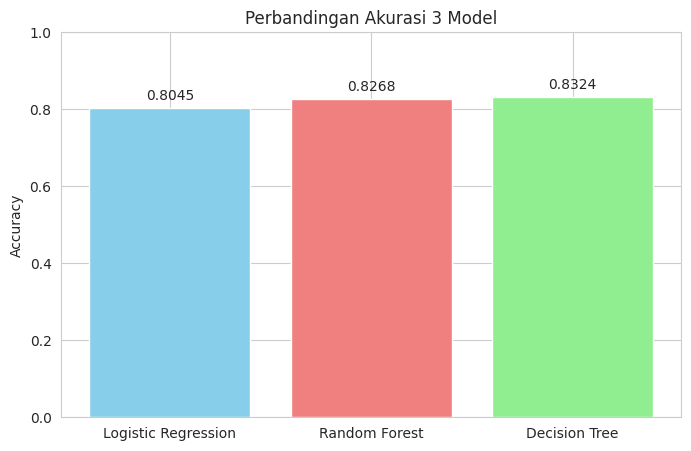

In [ ]:
print("PERBANDINGAN KETIGA MODEL")

print("\n{:^20} {:^10} {:^10} {:^10} {:^10}".format("Model", "Accuracy", "Precision", "Recall", "F1-Score"))
print("-"*70)
print("{:^20} {:^10.4f} {:^10.4f} {:^10.4f} {:^10.4f}".format("Logistic Regression", acc_logreg, prec_logreg, rec_logreg, f1_logreg))
print("{:^20} {:^10.4f} {:^10.4f} {:^10.4f} {:^10.4f}".format("Random Forest", acc_rf, prec_rf, rec_rf, f1_rf))
print("{:^20} {:^10.4f} {:^10.4f} {:^10.4f} {:^10.4f}".format("Decision Tree", acc_dt, prec_dt, rec_dt, f1_dt))

models = ['Logistic Regression', 'Random Forest', 'Decision Tree']
accuracies = [acc_logreg, acc_rf, acc_dt]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.ylabel('Accuracy')
plt.title('Perbandingan Akurasi 3 Model')
plt.ylim(0, 1)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.4f}', ha='center')
plt.show()


Kesimpulan

In [ ]:
# Cari model dengan akurasi tertinggi
models_acc = {
    "Logistic Regression": acc_logreg,
    "Random Forest": acc_rf,
    "Decision Tree": acc_dt
}
best_model = max(models_acc, key=models_acc.get)
best_acc = models_acc[best_model]

print(f"\nMODEL TERBAIK: {best_model}")
print(f"Akurasi tertinggi: {best_acc:.4f} ({best_acc*100:.2f}%)")

print("\nALASAN RANDOM FOREST LEBIH BAIK")

print("""
1. Ensemble Method
   Random Forest menggabungkan banyak Decision Tree (biasanya 100 atau lebih)
   lalu mengambil suara terbanyak untuk menentukan prediksi.
   Ini membuat model lebih stabil dan akurat.

2. Menghindari Overfitting
   Decision Tree tunggal cenderung overfitting (hafal data training,
   tapi jelek di data baru). Random Forest mengurangi overfitting
   karena menggunakan rata-rata dari banyak pohon.

3. Tahan Terhadap Outlier
   Random Forest lebih robust (tahan) terhadap outlier dan noise
   dalam data dibandingkan Logistic Regression.

4. Menangkap Pola Non-Linear
   Random Forest bisa menangkap hubungan kompleks dan non-linear
   antar fitur, sementara Logistic Regression hanya bisa
   menangkap hubungan linear.

5. Feature Importance
   Random Forest bisa memberikan informasi fitur mana yang paling
   berpengaruh terhadap prediksi (misal: Sex, Age, Fare).
""")


MODEL TERBAIK: Decision Tree
Akurasi tertinggi: 0.8324 (83.24%)

ALASAN RANDOM FOREST LEBIH BAIK

1. Ensemble Method
   Random Forest menggabungkan banyak Decision Tree (biasanya 100 atau lebih)
   lalu mengambil suara terbanyak untuk menentukan prediksi.
   Ini membuat model lebih stabil dan akurat.

2. Menghindari Overfitting
   Decision Tree tunggal cenderung overfitting (hafal data training,
   tapi jelek di data baru). Random Forest mengurangi overfitting
   karena menggunakan rata-rata dari banyak pohon.

3. Tahan Terhadap Outlier
   Random Forest lebih robust (tahan) terhadap outlier dan noise
   dalam data dibandingkan Logistic Regression.

4. Menangkap Pola Non-Linear
   Random Forest bisa menangkap hubungan kompleks dan non-linear
   antar fitur, sementara Logistic Regression hanya bisa
   menangkap hubungan linear.

5. Feature Importance
   Random Forest bisa memberikan informasi fitur mana yang paling
   berpengaruh terhadap prediksi (misal: Sex, Age, Fare).



Prediksi model

In [ ]:
print("="*50)
print("PREDIKSI DENGAN MODEL RANDOM FOREST")
print("="*50)

# Model terbaik yang sudah dilatih (dari kode sebelumnya)
model_terbaik = rf  # Random Forest

print("\n1. PREDIKSI PADA 179 DATA TEST")
print("-"*40)

y_pred_final = model_terbaik.predict(X_test)

print("\n10 HASIL PREDIKSI PERTAMA:")
print("{:<5} {:<12} {:<12}".format("No", "Aktual", "Prediksi"))
print("-"*35)
for i in range(10):
    print("{:<5} {:<12} {:<12}".format(i+1, y_test.iloc[i], y_pred_final[i]))

# Akurasi
from sklearn.metrics import accuracy_score
akurasi = accuracy_score(y_test, y_pred_final)
print(f"\nAkurasi prediksi: {akurasi:.2%}")

print("\n2. PREDIKSI PENUMPANG BARU")
print("-"*40)

# Buat data penumpang baru
penumpang_baru = pd.DataFrame([{
    'Pclass': 1,
    'Sex': 0,        # 0 = female
    'Age': 28,
    'SibSp': 0,
    'Parch': 0,
    'Fare': 72,
    'Embarked': 2    # 2 = S
}])

# Scaling (pakai scaler yang sama)
penumpang_baru[['Age', 'Fare']] = scaler.transform(penumpang_baru[['Age', 'Fare']])

# Prediksi
pred = model_terbaik.predict(penumpang_baru)[0]
prob = model_terbaik.predict_proba(penumpang_baru)[0]

print("Data penumpang: Wanita, Kelas 1, Usia 28, Fare $72")
print(f"\nHasil prediksi: {'SELAMAT ✅' if pred == 1 else 'TIDAK SELAMAT ❌'}")
print(f"Probabilitas selamat: {prob[1]*100:.1f}%")
print(f"Probabilitas tidak selamat: {prob[0]*100:.1f}%")

PREDIKSI DENGAN MODEL RANDOM FOREST

1. PREDIKSI PADA 179 DATA TEST
----------------------------------------

10 HASIL PREDIKSI PERTAMA:
No    Aktual       Prediksi    
-----------------------------------
1     0            0           
2     0            0           
3     1            0           
4     0            0           
5     1            1           
6     1            0           
7     1            1           
8     0            1           
9     0            0           
10    0            0           

Akurasi prediksi: 82.68%

2. PREDIKSI PENUMPANG BARU
----------------------------------------
Data penumpang: Wanita, Kelas 1, Usia 28, Fare $72

Hasil prediksi: SELAMAT ✅
Probabilitas selamat: 98.0%
Probabilitas tidak selamat: 2.0%
